In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import glob
import os
from functools import reduce
import ee
import time

In [4]:
#GRI3_Import_shp
Zamb_districts_gdf = gpd.read_file(r"C:\Users\flavi\OneDrive - Africa Specialty Risks Ltd\ASR-Parametric_Research_Study\africa_risk\Drought\Output\Zambia\Files\Zambia_Administrative_Boundaries_Districts_2020_-7037893626831916322\NSDI_Zambia_Districts_2022.shp")
#Zamb_districts_gdf.head()
#print(Zamb_districts_gdf['PROVINCE'].unique())
#convert crs 3857 to gcs 4326
Zamb_districts_4326 = Zamb_districts_gdf.to_crs(epsg=4326)
print("Zamb_districts_4326 CRS:", Zamb_districts_4326.crs)

Zamb_districts_4326 CRS: EPSG:4326


In [5]:
Southprov_districts_4326 = Zamb_districts_4326[(Zamb_districts_4326['PROVINCE'] == 'Southern')]
Southprov_districts_4326.to_file(r"C:\Users\flavi\OneDrive - Africa Specialty Risks Ltd\ASR-Parametric_Research_Study\africa_risk\Drought\Output\Zambia\Output\Southprov_districts_4326.shp")

In [6]:
Southprov_districts_4326_gdf = gpd.read_file(r"C:\Users\flavi\OneDrive - Africa Specialty Risks Ltd\ASR-Parametric_Research_Study\africa_risk\Drought\Output\Zambia\Output\Southprov_districts_4326.shp")
Southprov_districts_4326_gdf.head()
#print(Southprov_districts_4326_gdf['DISTRICT'].unique())
#print("Southprov_districts_4326:", Southprov_districts_4326.crs)

,FEATURE_TY,PROVINCE,Area_km,PROV_CODE,DIST_CODE,DISTRICT,geometry
0,District Town,Southern,2789.509617,109,109001,Chikankanta,"POLYGON ((28.58997 -15.90694, 28.58993 -15.906..."
1,District Town,Southern,1395.218903,109,105002,Chirundu,"POLYGON ((28.9341 -15.94181, 28.92999 -15.9449..."
2,Provincial Town,Southern,5153.656710,109,109002,Choma,"POLYGON ((26.99834 -16.25078, 27.01642 -16.288..."
3,District Town,Southern,3999.940878,109,109003,Gwembe,"POLYGON ((28.39719 -16.66534, 28.39684 -16.665..."
4,District Town,Southern,15758.863354,109,101004,Itezhi-Tezhi,"POLYGON ((27.27496 -15.72405, 27.27491 -15.723..."


C:\Users\flavi\AppData\Local\Temp\ipykernel_27356\2134679226.py:11: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right')
C:\Users\flavi\AppData\Local\Temp\ipykernel_27356\2134679226.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


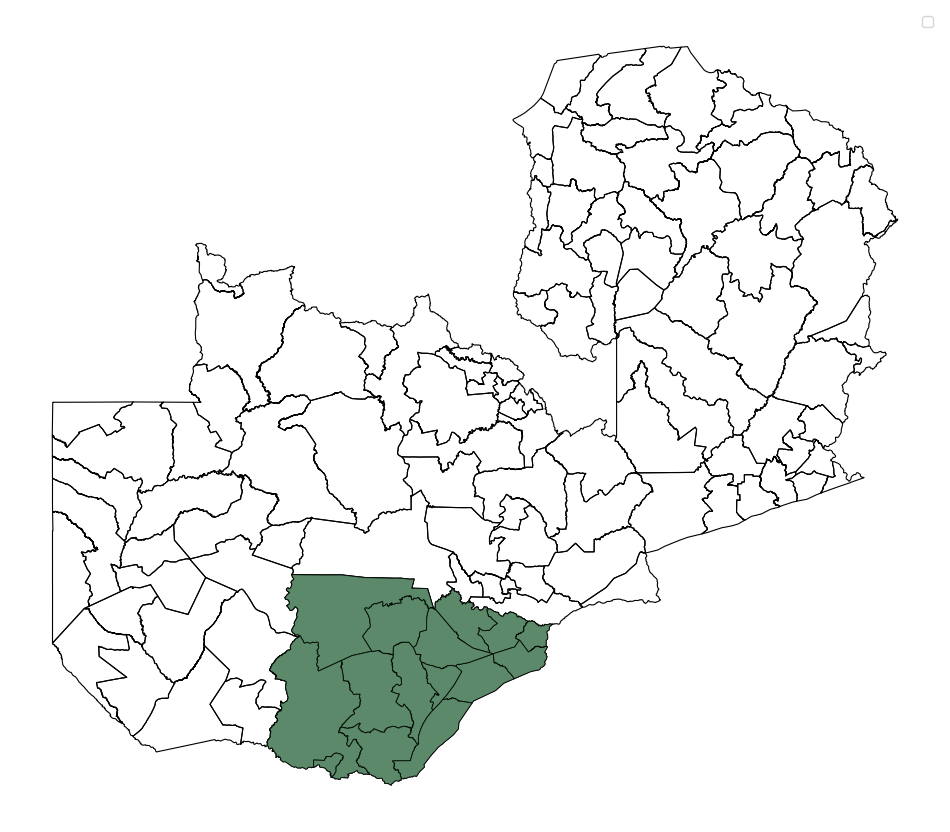

In [11]:
fig, ax = plt.subplots(figsize=(12, 12))
# 1. Zambia provinces (flat background)
Zamb_districts_4326.plot(ax=ax,facecolor='none',edgecolor='black',linewidth=0.8,label='Provinces')
# 2. All districts
#Zambia_districts.plot(ax=ax,facecolor='lightgray',edgecolor='gray',linewidth=0.3,alpha=0.6,label='Districts')
# 3. Southern‑Province districts (on top)
Southprov_districts_4326_gdf.plot(ax=ax,facecolor='#4a7c59',edgecolor='black',linewidth=0.5,alpha=0.9,label='Southern Province')
# Clean up
ax.set_axis_off()
# Add legend and caption
ax.legend(loc='upper right')
#plt.figtext(0.5, 0.01,"Figure 1: Zambia Provinces and Districts (Admin 1 & 2), Southern Province highlighted",ha='center',fontsize=10,style='italic')
# Save and show
#plt.savefig(r"C:\Users\flavi\OneDrive - Africa Specialty Risks Ltd\ASR-Parametric_Research_Study\africa_risk\Drought\Output\Zambia_Southern_districts_map.png",dpi=300,bbox_inches='tight')
plt.show()   # this is key to actually open the window

In [44]:
# Force re-authrentication to get fresh code token with the right scopes
ee.Authenticate(force=True)

#Re-intialize with GCP ID
ee.Initialize(project="vernal-parser-412016")

Enter verification code:  4/1Aci98E919PSDEsH13o7LXTV0LbtNesxTRkhNC5-qfeUIM_qTiSkOxM9yQHw



Successfully saved authorization token.


In [48]:
# Load your Final Agricultural Districts Asset
asset_id = f"projects/vernal-parser-41201/assets/Zambia_Administrative_Boundaries_Districts"
Zambia_Administrative_Boundaries_Districts = ee.FeatureCollection(asset_id)

# One single collection for the whole period
full_collection = (ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
                   .filterDate('2000-01-01', '2025-12-31')
                   .select(BANDS))
# Map your extraction function once
all_features = full_collection.map(extract_daily_features).flatten()
# Export one single CSV file (much easier to manage in Excel/Python)
task = ee.batch.Export.table.toDrive(
    collection=all_features,
    description='ERA5_Zambia_Monthly_2000_2025',
    folder=EXPORT_FOLDER,
    fileNamePrefix='zambia_monthly_full',
    fileFormat='CSV'
)
task.start()

EEException: Request had insufficient authentication scopes.

In [29]:
years = range(2000, 2026)   # 2000 to 2025 inclusive
task_ids = []

for year in years:
    print(f"Processing year {year}...")
    
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    
    # One single collection for the whole period
    full_collection = (ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
                   .filterDate('2000-01-01', '2025-12-31')
                   .select(BANDS))
# Map your extraction function once
all_features = full_collection.map(extract_daily_features).flatten()
# Export one single CSV file (much easier to manage in Excel/Python)
task = ee.batch.Export.table.toDrive(
    collection=all_features,
    description='ERA5_Zambia_Monthly_2000_2025',
    folder=EXPORT_FOLDER,
    fileNamePrefix='zambia_monthly_full',
    fileFormat='CSV'
)
task.start()
task_ids.append(task.id)
print(f"  → Task started: {task.id}")
# Small delay to avoid overwhelming the task queue
time.sleep(2)

print("\nAll tasks submitted. Monitor with:")
print("  earthengine task list --status RUNNING")

Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...
Processing year 2014...
Processing year 2015...
Processing year 2016...
Processing year 2017...
Processing year 2018...
Processing year 2019...
Processing year 2020...
Processing year 2021...
Processing year 2022...
Processing year 2023...
Processing year 2024...
Processing year 2025...


EEException: Request had insufficient authentication scopes.

In [32]:
#projects/vernal-parser-412016/assets/Zambia_Administrative_Boundaries_Districts
#!/usr/bin/env python3
"""
Export daily ERA5-Land data for Zambia districts as one CSV per year (2000–2025).
Run: python zambia_export_yearly.py
"""
import ee
import time
# Initialize Earth Engine
try:
    ee.Initialize()
except Exception as e:
    print("Initialization failed. Run 'earthengine authenticate' and 'earthengine set_project <your-project-id>' first.")
    raise
# CONFIGURATION – UPDATE THESE
ASSET_PATH = 'projects/vernal-parser-412016/assets/Zambia_Administrative_Boundaries_Districts' # CHANGE THIS to your actual asset path
EXPORT_FOLDER = 'Zambia-matrix' # Google Drive folder
BANDS = ['temperature_2m', 'total_precipitation_sum']

# Load districts
districts = ee.FeatureCollection(ASSET_PATH)
print(f"Loaded {districts.size().getInfo()} districts")
# FUNCTION TO EXTRACT DAILY VALUES FOR A SINGLE IMAGE
def extract_daily_features(image):
    """Return a FeatureCollection with district averages for one day."""
    date_str = image.date().format('YYYY-MM-dd')
    year = image.date().get('year')
    month = image.date().get('month')
    day = image.date().get('day')
    def map_district(district):
        stats = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=district.geometry(),
            scale=11132,          # ERA5-Land native resolution
            maxPixels=1e9
        )
        return ee.Feature(None, {
            'district': district.get('District'),   # CHANGE property name if needed
            'year': year,
            'month': month,
            'day': day,
            'date': date_str,
            'temperature_2m': stats.get('temperature_2m'),
            'precipitation': stats.get('total_precipitation_sum')
        })   
    return districts.map(map_district)
# LOOP OVER YEARS AND SUBMIT EXPORT TASKS
years = range(2000, 2026)   # 2000 to 2025 inclusive
task_ids = []
for year in years:
    print(f"Processing year {year}...")
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    # Filter daily collection for this year
    yearly_collection = (ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
                         .filterDate(start, end)
                         .select(BANDS))
    # Map the extraction function over all days and flatten into one FeatureCollection
    yearly_features = yearly_collection.map(extract_daily_features).flatten()
    # Submit export task
    task = ee.batch.Export.table.toDrive(
        collection=yearly_features,
        description=f'ERA5_Zambia_{year}_Daily',
        folder=EXPORT_FOLDER,
        fileNamePrefix=f'zambia_daily_{year}',
        fileFormat='CSV'
    )
    task.start()
    task_ids.append(task.id)
    print(f"  → Task started: {task.id}")
    # Small delay to avoid overwhelming the task queue
    time.sleep(2)
print("\nAll tasks submitted. Monitor with:")
print("earthengine task list --status RUNNING")

Loaded 116 districts
Processing year 2000...


EEException: Request had insufficient authentication scopes.